In [12]:
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    widgets = None
from IPython.display import display


,dataset,file,candidates,accepted,rejected,steps,sustained,max_z,max_force_n
0,swing,hassan_swing.csv,13,12,1,12,0,22.5,647.8
1,2pt,hassan_2pt_left_crutch_right_damaged.csv,10,9,1,9,0,58.1,473.7
2,3pt,hassan3pt_left_crutch_left_damaged.csv,16,12,4,12,0,11.6,164.5
3,4pt,hassandata1_4pt_left_crutch_right_damaged.csv,13,9,4,9,0,70.6,171.4


,dataset,start_s,release_s,duration_s,kind,accepted,reject_reason,peak_amp,area
0,swing,1.683,3.234,1.551,step,True,,77.849923,52.721076
1,swing,3.861,4.719,0.858,step,True,,71.825967,34.615973
2,swing,6.138,6.798,0.660,step,True,,68.303506,29.237019
3,swing,8.184,8.976,0.792,step,True,,80.680807,35.769629
4,swing,10.560,11.187,0.627,step,True,,68.867103,26.297243
5,swing,12.441,13.530,1.089,step,True,,74.539593,40.647301
6,swing,14.421,17.061,2.640,step,True,,108.038349,159.098424
7,swing,17.754,18.612,0.858,step,True,,61.038100,30.454897
8,swing,19.470,20.031,0.561,step,True,,69.011197,25.072018
9,swing,21.681,22.209,0.528,step,False,small_area,56.604370,20.019092


dataset                                                     3pt
file                     hassan3pt_left_crutch_left_damaged.csv
rows                                                       1408
duration_s                                               46.431
mag_axis_for_detector                                     mz_uT
use_abs_field                                              True
startup_b0_uT                                        769.576069
candidates                                                   16
accepted                                                     12
rejected                                                      4
steps                                                        12
sustained                                                     0
max_z                                                  11.63964
max_r_diff_mm                                          0.513061
max_force_n                                          164.452998
Name: peak-release summary, dtype: objec

,dataset,start_s,release_s,duration_s,kind,accepted,reject_reason,peak_amp,area
0,3pt,1.023,1.848,0.825,step,False,"small_peak,small_area",34.891882,20.716845
1,3pt,3.300,4.488,1.188,step,True,,73.049693,55.899387
2,3pt,6.435,7.755,1.320,step,True,,84.165916,76.229597
3,3pt,9.735,10.692,0.957,step,True,,74.856642,46.425476
4,3pt,12.870,14.058,1.188,step,True,,85.578158,63.220663
5,3pt,16.071,17.061,0.990,step,True,,84.343318,56.419013
6,3pt,19.833,21.351,1.518,step,False,"small_peak,small_area",28.052567,29.430356
7,3pt,22.275,23.298,1.023,step,True,,46.274327,30.583483
8,3pt,24.651,25.608,0.957,step,True,,70.367471,40.247581
9,3pt,26.433,28.380,1.947,step,True,,94.531014,144.997693


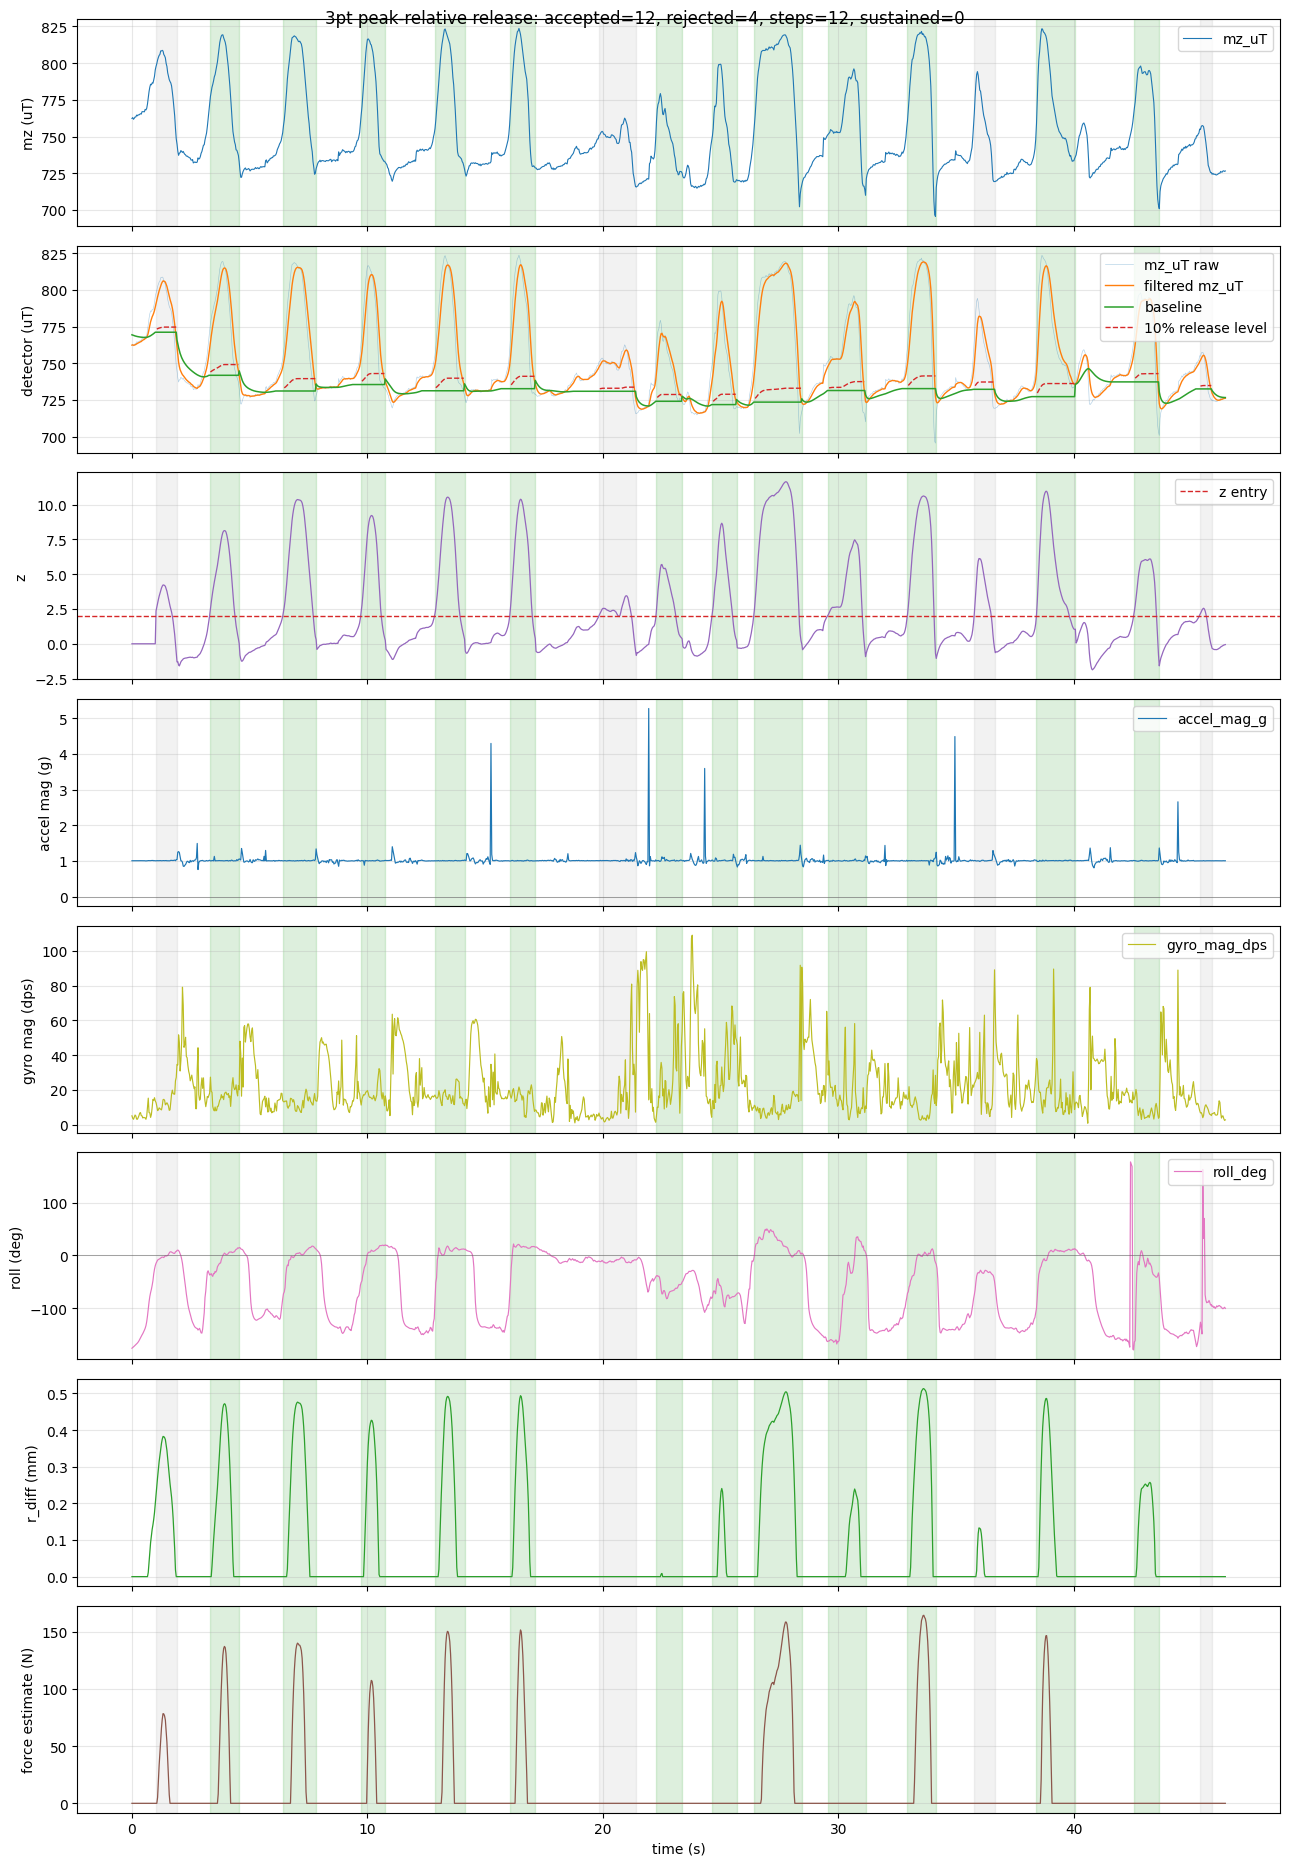

In [18]:
twopt_path = Path("hassan_2pt_left_crutch_right_damaged.csv")
threept_path = Path("hassan3pt_left_crutch_left_damaged.csv")
fourpt_path = Path("hassandata1_4pt_left_crutch_right_damaged.csv")
swing_path = Path("hassan_swing.csv")

DATASET_PATHS = {
    "swing": swing_path,
    "2pt": twopt_path,
    "3pt": threept_path,
    "4pt": fourpt_path,
}
DATASET_DIR = Path("Rig_tests_and_analysis")

# Force/r_diff tuning.
MAG_AXIS = "mz_uT"      # choose: mx_uT, my_uT, mz_uT, or mag_norm_uT
USE_ABS_FIELD = True    # use abs(axis) for single-axis force proxy
R0_MM = 25.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5

# Peak-relative release step detector tuning.
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 50
Z_ENTER = 2.0
RELEASE_FRACTION = 0.1
RELEASE_CONFIRM_MS = 50.0
REFRACTORY_MS = 50.0
POST_RELEASE_BASELINE_SAMPLES = BASELINE_WINDOW_SAMPLES
SUSTAINED_CUTOFF_S = 5.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
MIN_DURATION_S = 0.50
MIN_PEAK_FRAC_OF_MEDIAN = 0.60
MIN_AREA_FRAC_OF_MEDIAN = 0.60

RAW_CAPTURE_COLS = [
    "seq", "timestamp_ms",
    "ax_g", "ay_g", "az_g",
    "gx_dps", "gy_dps", "gz_dps",
    "roll_deg", "pitch_deg", "yaw_deg",
    "mx_uT", "my_uT", "mz_uT",
]


def resolve_capture_path(path):
    path = Path(path)
    if path.exists():
        return path

    analysis_path = DATASET_DIR / path
    if analysis_path.exists():
        return analysis_path

    return path


def load_hassan_capture_csv(path):
    path = resolve_capture_path(path)
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if parts[0] == "seq":
                continue
            if len(parts) != len(RAW_CAPTURE_COLS):
                continue
            try:
                rows.append([float(p) for p in parts])
            except ValueError:
                continue

    if not rows:
        return pd.DataFrame(), path

    df = pd.DataFrame(rows, columns=RAW_CAPTURE_COLS)
    df["seq"] = df["seq"].astype(int)
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["accel_mag_g"] = np.sqrt(df["ax_g"]**2 + df["ay_g"]**2 + df["az_g"]**2)
    df["gyro_mag_dps"] = np.sqrt(df["gx_dps"]**2 + df["gy_dps"]**2 + df["gz_dps"]**2)
    return df, path


def add_force_columns(df):
    df = df.copy()
    df["mag_norm_uT"] = np.sqrt(df["mx_uT"]**2 + df["my_uT"]**2 + df["mz_uT"]**2)

    field = df[MAG_AXIS]
    if USE_ABS_FIELD:
        field = field.abs()
    df["detector_signal_uT"] = field
    df["detector_signal_lpf_uT"] = field.ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    b0 = startup["detector_signal_lpf_uT"].mean()
    ratio = b0 / df["detector_signal_lpf_uT"]
    ratio = ratio.where((ratio > 0) & np.isfinite(ratio), np.nan)
    df["r_mm"] = R0_MM * np.cbrt(ratio)
    df["r_diff_mm"] = (R0_MM - df["r_mm"]).clip(lower=0.0)
    df["force_n"] = (FORCE_SLOPE * df["r_diff_mm"] + FORCE_INTERCEPT).clip(lower=0.0)
    return df, b0


def event_area(df, start_s, release_s, baseline):
    event_df = df[(df["time_s"] >= start_s) & (df["time_s"] <= release_s)]
    if len(event_df) < 2:
        return 0.0
    y = (event_df["detector_signal_lpf_uT"] - baseline).clip(lower=0.0)
    return float(np.trapz(y, event_df["time_s"]))


def classify_rejections(events_df):
    if events_df.empty:
        events_df["accepted"] = []
        events_df["reject_reason"] = []
        return events_df

    median_peak_amp = events_df["peak_amp"].median()
    median_area = events_df["area"].median()

    accepted = []
    reasons = []
    for row in events_df.itertuples(index=False):
        reason_parts = []
        if row.duration_s < MIN_DURATION_S:
            reason_parts.append("short")
        if median_peak_amp > 0 and row.peak_amp < MIN_PEAK_FRAC_OF_MEDIAN * median_peak_amp:
            reason_parts.append("small_peak")
        if median_area > 0 and row.area < MIN_AREA_FRAC_OF_MEDIAN * median_area:
            reason_parts.append("small_area")
        accepted.append(not reason_parts)
        reasons.append(",".join(reason_parts))

    events_df = events_df.copy()
    events_df["accepted"] = accepted
    events_df["reject_reason"] = reasons
    events_df["median_peak_amp"] = median_peak_amp
    events_df["median_area"] = median_area
    return events_df


def run_peak_release_pipeline(df):
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    startup_std_floor = max(startup["detector_signal_lpf_uT"].std(ddof=1), STD_FLOOR)
    baseline_window = deque(startup["detector_signal_lpf_uT"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
        return mean, max(std, startup_std_floor)

    def update_rolling_baseline(window, b):
        window.append(b)
        return window_stats(window)

    baseline_mean, baseline_std = window_stats(baseline_window)
    state = "idle"
    load_start_t = None
    release_candidate_t = None
    last_release_t = -1e9
    post_release_baseline_samples = 0
    baseline_at_entry = None
    peak_signal = None
    release_level = np.nan
    events = []

    states = []
    baseline_means = []
    baseline_stds = []
    z_scores = []
    release_levels = []
    peak_values = []

    for row in df.itertuples(index=False):
        t = row.time_s
        b = row.detector_signal_lpf_uT

        if t <= STARTUP_ZERO_S:
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            states.append("zeroing")
            baseline_means.append(baseline_mean)
            baseline_stds.append(baseline_std)
            z_scores.append(0.0)
            release_levels.append(np.nan)
            peak_values.append(np.nan)
            continue

        z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

        if state == "idle":
            can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
            if can_start and z >= Z_ENTER:
                state = "loaded"
                load_start_t = t
                release_candidate_t = None
                baseline_at_entry = baseline_mean
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
                post_release_baseline_samples = 0
            elif post_release_baseline_samples > 0:
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
                post_release_baseline_samples -= 1
            release_levels.append(np.nan)
            peak_values.append(np.nan)

        elif state == "loaded":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)

            if b <= release_level:
                state = "releasing"
                release_candidate_t = t

            release_levels.append(release_level)
            peak_values.append(peak_signal)

        elif state == "releasing":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)

            if b > release_level:
                state = "loaded"
                release_candidate_t = None
            elif (t - release_candidate_t) * 1000.0 >= RELEASE_CONFIRM_MS:
                release_t = release_candidate_t
                duration_s = release_t - load_start_t
                kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
                peak_amp = peak_signal - baseline_at_entry
                area = event_area(df, load_start_t, release_t, baseline_at_entry)
                events.append({
                    "start_s": load_start_t,
                    "release_s": release_t,
                    "confirm_s": t,
                    "duration_s": duration_s,
                    "kind": kind,
                    "baseline_at_entry": baseline_at_entry,
                    "peak_signal_uT": peak_signal,
                    "peak_amp": peak_amp,
                    "area": area,
                    "release_level": release_level,
                })

                # Start the next unloaded baseline at the detected release point,
                # not at the later confirmation point.
                release_samples = df.loc[
                    (df["time_s"] >= release_t) & (df["time_s"] <= t),
                    "detector_signal_lpf_uT",
                ]
                baseline_window.clear()
                for sample in release_samples:
                    baseline_window.append(sample)
                baseline_mean, baseline_std = window_stats(baseline_window)
                post_release_baseline_samples = max(
                    POST_RELEASE_BASELINE_SAMPLES - len(release_samples),
                    0,
                )

                state = "idle"
                load_start_t = None
                release_candidate_t = None
                last_release_t = t
                baseline_at_entry = None
                peak_signal = None
                release_level = np.nan

            release_levels.append(release_level)
            peak_values.append(peak_signal if peak_signal is not None else np.nan)

        states.append(state)
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)

    out = df.copy()
    out["state"] = states
    out["baseline_mean"] = baseline_means
    out["baseline_std"] = baseline_stds
    out["z_score"] = z_scores
    out["release_level"] = release_levels
    out["peak_signal_uT"] = peak_values
    events_df = classify_rejections(pd.DataFrame(events))
    return out, events_df


def analyze_dataset(dataset_name):
    csv_path = DATASET_PATHS[dataset_name]
    raw_df, csv_path = load_hassan_capture_csv(csv_path)
    if raw_df.empty:
        print(f"No raw 14-column Hassan capture rows in {csv_path}")
        return None, pd.DataFrame(), csv_path, np.nan

    force_df, startup_b0 = add_force_columns(raw_df)
    detected_df, events_df = run_peak_release_pipeline(force_df)
    if len(events_df):
        events_df = events_df.copy()
        events_df.insert(0, "dataset", dataset_name)
        events_df.insert(1, "file", str(csv_path))
    return detected_df, events_df, csv_path, startup_b0


def plot_peak_release_dataset(dataset_name):
    detected_df, events_df, csv_path, startup_b0 = analyze_dataset(dataset_name)
    if detected_df is None:
        return

    accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
    rejected_df = events_df[~events_df["accepted"]] if len(events_df) else events_df
    steps = int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0
    sustained = int((accepted_df["kind"] == "sustained").sum()) if len(accepted_df) else 0

    display(pd.Series({
        "dataset": dataset_name,
        "file": str(csv_path),
        "rows": len(detected_df),
        "duration_s": detected_df["time_s"].iloc[-1],
        "mag_axis_for_detector": MAG_AXIS,
        "use_abs_field": USE_ABS_FIELD,
        "startup_b0_uT": startup_b0,
        "candidates": len(events_df),
        "accepted": len(accepted_df),
        "rejected": len(rejected_df),
        "steps": steps,
        "sustained": sustained,
        "max_z": detected_df["z_score"].max(),
        "max_r_diff_mm": detected_df["r_diff_mm"].max(),
        "max_force_n": detected_df["force_n"].max(),
    }, name="peak-release summary"))

    cols = ["dataset", "start_s", "release_s", "duration_s", "kind", "accepted", "reject_reason", "peak_amp", "area"]
    display(events_df[cols] if len(events_df) else events_df)

    fig, axs = plt.subplots(8, 1, figsize=(13, 19), sharex=True)

    axs[0].plot(detected_df["time_s"], detected_df["mz_uT"], lw=0.8, label="mz_uT")
    axs[0].set_ylabel("mz (uT)")
    axs[0].legend(loc="upper right")
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(detected_df["time_s"], detected_df["detector_signal_uT"], lw=0.45, alpha=0.35, label=f"{MAG_AXIS} raw")
    axs[1].plot(detected_df["time_s"], detected_df["detector_signal_lpf_uT"], lw=1.0, label=f"filtered {MAG_AXIS}")
    axs[1].plot(detected_df["time_s"], detected_df["baseline_mean"], lw=1.1, label="baseline")
    axs[1].plot(detected_df["time_s"], detected_df["release_level"], lw=1.0, ls="--", color="C3", label=f"{RELEASE_FRACTION:.0%} release level")
    axs[1].set_ylabel("detector (uT)")
    axs[1].legend(loc="upper right")
    axs[1].grid(True, alpha=0.3)

    axs[2].plot(detected_df["time_s"], detected_df["z_score"], lw=0.9, color="C4")
    axs[2].axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="z entry")
    axs[2].set_ylabel("z")
    axs[2].legend(loc="upper right")
    axs[2].grid(True, alpha=0.3)

    axs[3].plot(detected_df["time_s"], detected_df["accel_mag_g"], lw=0.85, color="C0", label="accel_mag_g")
    axs[3].axhline(0, color="0.35", lw=0.7, alpha=0.5)
    axs[3].set_ylabel("accel mag (g)")
    axs[3].legend(loc="upper right")
    axs[3].grid(True, alpha=0.3)

    axs[4].plot(detected_df["time_s"], detected_df["gyro_mag_dps"], lw=0.85, color="C8", label="gyro_mag_dps")
    axs[4].set_ylabel("gyro mag (dps)")
    axs[4].legend(loc="upper right")
    axs[4].grid(True, alpha=0.3)

    axs[5].plot(detected_df["time_s"], detected_df["roll_deg"], lw=0.85, color="C6", label="roll_deg")
    axs[5].axhline(0, color="0.35", lw=0.7, alpha=0.5)
    axs[5].set_ylabel("roll (deg)")
    axs[5].legend(loc="upper right")
    axs[5].grid(True, alpha=0.3)

    axs[6].plot(detected_df["time_s"], detected_df["r_diff_mm"], lw=0.9, color="C2")
    axs[6].set_ylabel("r_diff (mm)")
    axs[6].grid(True, alpha=0.3)

    axs[7].plot(detected_df["time_s"], detected_df["force_n"], lw=0.9, color="C5")
    axs[7].set_ylabel("force estimate (N)")
    axs[7].set_xlabel("time (s)")
    axs[7].grid(True, alpha=0.3)

    for event in events_df.to_dict("records"):
        if not event["accepted"]:
            color = "0.5"
        elif event["kind"] == "step":
            color = "C2"
        else:
            color = "C1"
        alpha = 0.10 if not event["accepted"] else 0.16
        for ax in axs:
            ax.axvspan(event["start_s"], event["confirm_s"], color=color, alpha=alpha)

    fig.suptitle(
        f"{dataset_name} peak-relative release: accepted={len(accepted_df)}, rejected={len(rejected_df)}, "
        f"steps={steps}, sustained={sustained}"
    )
    plt.tight_layout()
    plt.show()


def compare_peak_release_datasets():
    rows = []
    all_events = []
    for dataset_name in DATASET_PATHS:
        detected_df, events_df, csv_path, _ = analyze_dataset(dataset_name)
        if detected_df is None:
            continue
        accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
        rejected_df = events_df[~events_df["accepted"]] if len(events_df) else events_df
        rows.append({
            "dataset": dataset_name,
            "file": str(csv_path),
            "candidates": len(events_df),
            "accepted": len(accepted_df),
            "rejected": len(rejected_df),
            "steps": int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0,
            "sustained": int((accepted_df["kind"] == "sustained").sum()) if len(accepted_df) else 0,
            "max_z": round(float(detected_df["z_score"].max()), 1),
            "max_force_n": round(float(detected_df["force_n"].max()), 1),
        })
        all_events.append(events_df)

    summary_df = pd.DataFrame(rows)
    events_table = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
    display(summary_df)
    cols = ["dataset", "start_s", "release_s", "duration_s", "kind", "accepted", "reject_reason", "peak_amp", "area"]
    display(events_table[cols] if len(events_table) else events_table)


compare_peak_release_datasets()

plot_peak_release_dataset("3pt")
